<a href="https://colab.research.google.com/github/AbhishekShah272002/Deep-Learning-and-NLP/blob/main/Student_Performance_PRediction_1NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("Student Performance.xlsx - Student_Performance.csv")

In [6]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
StudyHours,0
Attendance,0
InternalMarks,0
AssignmentScore,0
PracticalScore,0
FinalMarks,0
PlacementStatus,0


In [7]:
df=df.fillna(87)

In [8]:
df.head()

,Student_ID,Gender,StudyHours,Attendance,InternalMarks,AssignmentScore,PracticalScore,FinalMarks,PlacementStatus
0,STU001,Male,1.2,84,14,5,10,35,Not Placed
1,STU002,Male,2.2,87,16,5,10,44,Not Placed
2,STU003,Male,9.4,66,32,18,27,91,Not Placed
3,STU004,Female,8.8,78,32,15,27,88,Placed
4,STU005,Male,2.3,67,18,7,10,30,Not Placed


In [9]:
df.tail()

,Student_ID,Gender,StudyHours,Attendance,InternalMarks,AssignmentScore,PracticalScore,FinalMarks,PlacementStatus
395,STU396,Female,3.6,88,24,9,10,50,Not Placed
396,STU397,Male,4.6,70,21,8,12,56,Not Placed
397,STU398,Male,7.9,98,36,11,27,92,Placed
398,STU399,Male,3.9,77,23,10,12,40,Not Placed
399,STU400,Female,9.4,56,37,15,32,97,Not Placed


In [10]:
df.sample(50)

,Student_ID,Gender,StudyHours,Attendance,InternalMarks,AssignmentScore,PracticalScore,FinalMarks,PlacementStatus
170,STU171,Female,6.1,87,23,11,20,57,Not Placed
255,STU256,Female,5.5,94,25,9,14,47,Not Placed
99,STU100,Female,9.5,73,40,15,24,88,Placed
329,STU330,Female,9.0,66,36,13,23,77,Not Placed
208,STU209,Male,8.0,66,32,18,29,79,Not Placed
154,STU155,Female,2.0,77,14,5,10,36,Not Placed
230,STU231,Male,8.5,74,31,15,22,75,Placed
339,STU340,Female,4.9,67,20,11,14,56,Not Placed
233,STU234,Female,4.6,72,19,9,11,52,Not Placed
116,STU117,Female,2.8,86,16,5,10,31,Not Placed


In [11]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
StudyHours,0
Attendance,0
InternalMarks,0
AssignmentScore,0
PracticalScore,0
FinalMarks,0
PlacementStatus,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       400 non-null    object 
 1   Gender           400 non-null    object 
 2   StudyHours       400 non-null    float64
 3   Attendance       400 non-null    int64  
 4   InternalMarks    400 non-null    int64  
 5   AssignmentScore  400 non-null    int64  
 6   PracticalScore   400 non-null    int64  
 7   FinalMarks       400 non-null    int64  
 8   PlacementStatus  400 non-null    object 
dtypes: float64(1), int64(5), object(3)
memory usage: 28.3+ KB


In [13]:
df.shape

(400, 9)

In [14]:
df.describe()

,StudyHours,Attendance,InternalMarks,AssignmentScore,PracticalScore,FinalMarks
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,5.522750,76.437500,25.342500,11.090000,18.235000,61.305000
std,2.679488,12.489037,8.405166,4.292197,7.316667,21.495514
min,1.000000,55.000000,10.000000,5.000000,10.000000,30.000000
25%,3.100000,66.000000,19.000000,7.750000,10.000000,43.000000
50%,5.400000,76.000000,25.000000,11.000000,18.000000,59.500000
75%,7.900000,87.000000,32.000000,15.000000,24.000000,79.000000
max,9.900000,98.000000,40.000000,20.000000,35.000000,100.000000


In [15]:
df.mean(numeric_only=True)

,0
StudyHours,5.52275
Attendance,76.43750
InternalMarks,25.34250
AssignmentScore,11.09000
PracticalScore,18.23500
FinalMarks,61.30500


In [16]:
df.max(numeric_only=True)

,0
StudyHours,9.9
Attendance,98.0
InternalMarks,40.0
AssignmentScore,20.0
PracticalScore,35.0
FinalMarks,100.0


In [17]:
df.min(numeric_only=True)

,0
StudyHours,1.0
Attendance,55.0
InternalMarks,10.0
AssignmentScore,5.0
PracticalScore,10.0
FinalMarks,30.0


In [18]:
df.std(numeric_only=True)

,0
StudyHours,2.679488
Attendance,12.489037
InternalMarks,8.405166
AssignmentScore,4.292197
PracticalScore,7.316667
FinalMarks,21.495514


In [19]:
df.loc[5, 'Attendance'] = None
df.loc[10, 'FinalMarks'] = None

In [20]:
df['FinalMarks']  # select Single Column

,FinalMarks
0,35.0
1,44.0
2,91.0
3,88.0
4,30.0
...,...
395,50.0
396,56.0
397,92.0
398,40.0


In [21]:
df['PlacementStatus'].value_counts()

,count
PlacementStatus,
Not Placed,289
Placed,111


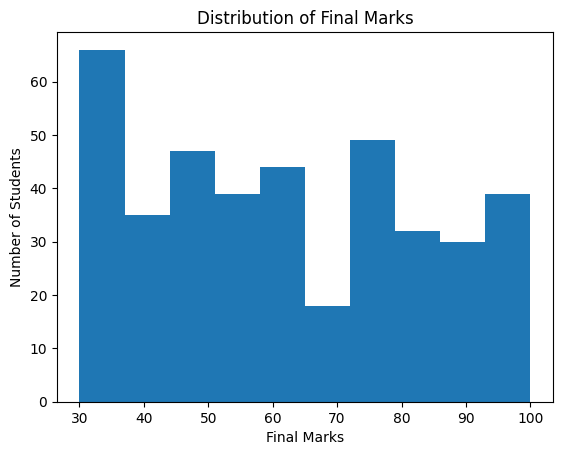

In [22]:
plt.hist(df['FinalMarks'])
plt.title('Distribution of Final Marks')
plt.xlabel('Final Marks')
plt.ylabel('Number of Students')
plt.show()

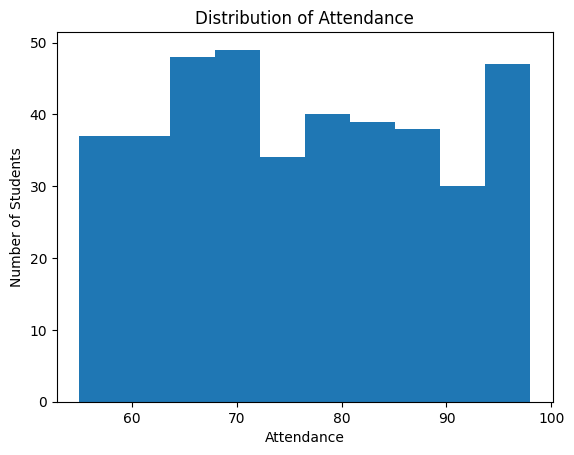

In [23]:
plt.hist(df['Attendance'])
plt.title('Distribution of Attendance')
plt.xlabel('Attendance')
plt.ylabel('Number of Students')
plt.show()

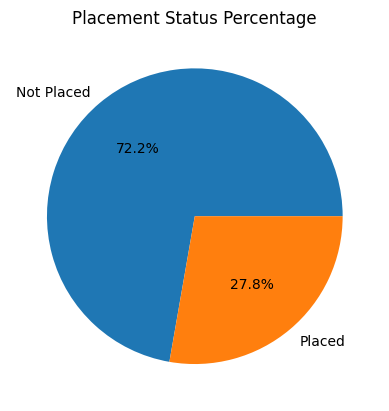

In [24]:
df['PlacementStatus'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Placement Status Percentage')
plt.ylabel('')
plt.show()

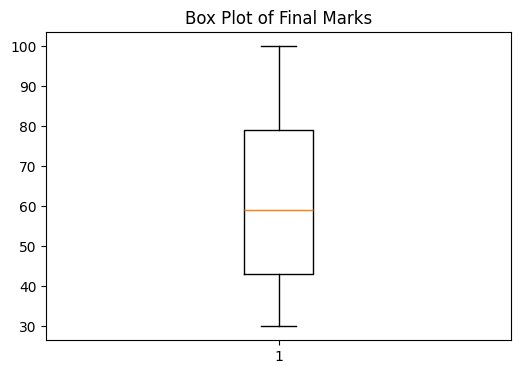

In [25]:
plt.figure(figsize=(6,4))

# Drop rows with NaN values in 'FinalMarks' before plotting
plt.boxplot(df['FinalMarks'].dropna())

plt.title('Box Plot of Final Marks')

plt.show()

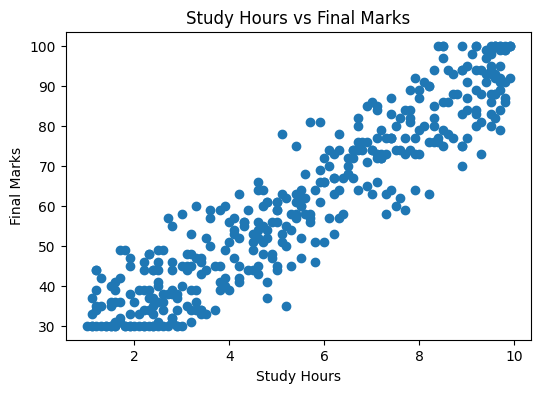

In [26]:
plt.figure(figsize=(6,4))

plt.scatter(
    df['StudyHours'],
    df['FinalMarks']
)

plt.xlabel('Study Hours')
plt.ylabel('Final Marks')
plt.title('Study Hours vs Final Marks')

plt.show()

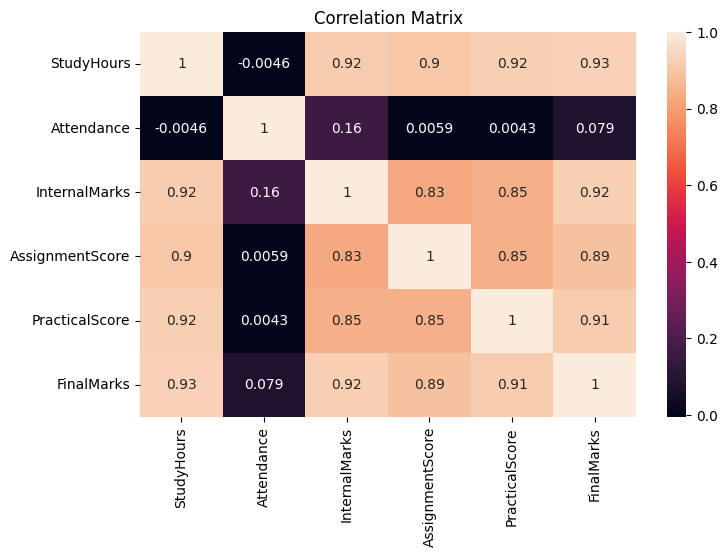

In [27]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True
)

plt.title('Correlation Matrix')

plt.show()

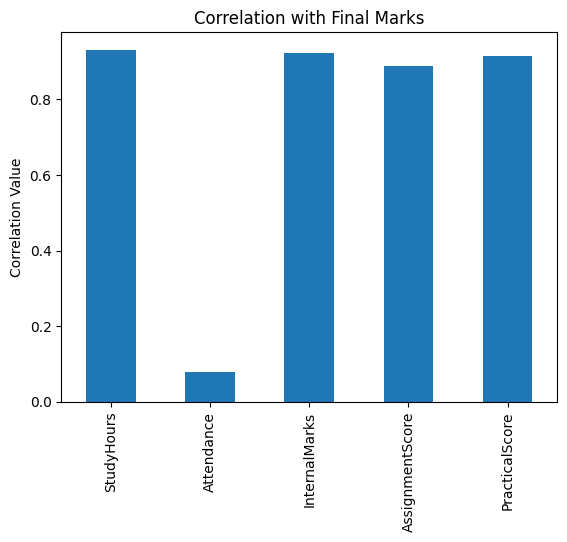

In [28]:
corr = df.select_dtypes(include='number').corr()['FinalMarks']

corr.drop('FinalMarks').plot(kind='bar')

plt.title('Correlation with Final Marks')
plt.ylabel('Correlation Value')
plt.show()


In [39]:
# Import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Create scaler object
scaler = MinMaxScaler()

# Select numerical columns
num_cols = ['StudyHours',
            'Attendance',
            'InternalMarks',
            'AssignmentScore',
            'PracticalScore',
            'FinalMarks']

# Apply Min-Max Scaling
df[num_cols] = scaler.fit_transform(df[num_cols])

In [37]:
df.head()

,Student_ID,Gender,StudyHours,Attendance,InternalMarks,AssignmentScore,PracticalScore,FinalMarks,PlacementStatus
0,STU001,1,0.022472,0.674419,0.133333,0.000000,0.00,0.071429,0
1,STU002,1,0.134831,0.744186,0.200000,0.000000,0.00,0.200000,0
2,STU003,1,0.943820,0.255814,0.733333,0.866667,0.68,0.871429,0
3,STU004,0,0.876404,0.534884,0.733333,0.666667,0.68,0.828571,1
4,STU005,1,0.146067,0.279070,0.266667,0.133333,0.00,0.000000,0


In [38]:
df[num_cols].min()

,0
StudyHours,0.0
Attendance,0.0
InternalMarks,0.0
AssignmentScore,0.0
PracticalScore,0.0
FinalMarks,0.0
